This code has been produced as a teaching resource for the UKSA space software, data and AI course run by the Space South Central Universities.

Contributors to this code includes: M. Chandar

<div class="alert alert-block alert-info"> <b>What is an API?</b>

API stands for Application Programming Interface, it's a sort of messenger between a server holding some data in a database and a client requesting that data (us). It usually does not matter how things work under the hood of an API so what it does, and how it does it, is no concern of ours! (At least for this tutorial.) The image below shows what we aim to do - create a program that will send API requests to the Space-Track API endpoint, and then receive the information that we have requested. 
</div>


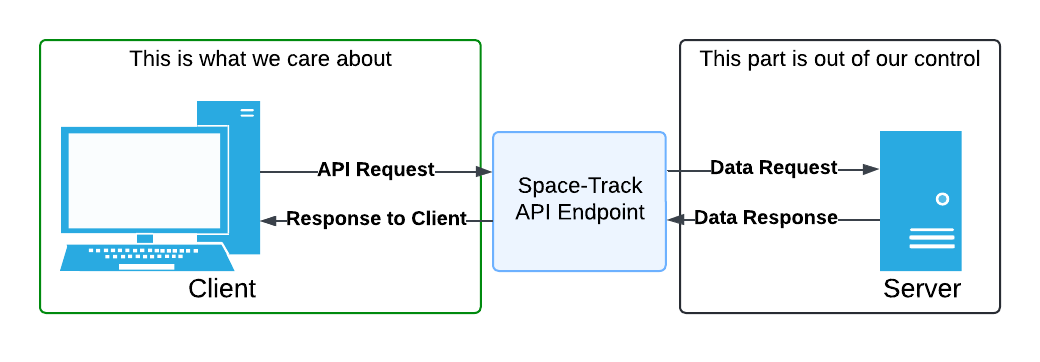

## Learning Outcome


<div class="alert alert-block alert-info"> <b> NOTE </b>
Before starting this notebook, it is important to create an account on https://www.space-track.org/ as your username and password will be used for the API authentication. In this notebook we will learn: 
    <ul>
        <li>How to access and query the Space Track API</li>
        <li>How to break down a Map datastructure.</li>
        <li>How to write data to a CSV file</li>
    </ul>
</div>






In [1]:
# The general code structure is taken from https://www.space-track.org/documentation#howto-api_python
# Import the necessary libaries for this
import requests
import json
import time
import configparser


In [2]:


baseURL = "https://www.space-track.org"
authPath = "/ajaxauth/login"

config = configparser.ConfigParser()

# Open the config.ini folder that is within the directory of this notebook.
# This is where you need to put the login information for Space-Track.org
config.read("./config.ini")
username = config.get("configuration","username")
password = config.get("configuration","password")



query = "/basicspacedata/query/class/gp/COUNTRY_CODE/UK/orderby/COUNTRY_CODE%20asc/limit/100/emptyresult/show";



In [7]:

# This is how we will access the Space-Track API. 
def api_access():
    with requests.Session() as session: # This provides cookie persistance so our login credentials are remembered for the whole session. 
        
        # Send the username and password data to the website.
        response = session.post(baseURL + authPath, data = {"identity":username, "password":password}) # When "adding" two or more strings, they concatenate.
        
        # Check whether the website got the data, a status_code of 200 means it did. 
        if response.status_code != 200:
            print(f"Could not POST for login: {response}") # f-strings are incredibly convieniant!
        
        response = session.get(baseURL + query) # Let's get the data.
    
        # Check whether this GET request is valid. 
        if response.status_code != 200:
            print(f"Could not GET data: {response}")
            
        response = json.loads(response.text)
       # print(response.keys())
    
        
        
        session.close()
        
        return response

In [15]:
response = api_access()
print(response[0]) # Just print the first satellite's information from the list.

{'CCSDS_OMM_VERS': '3.0', 'COMMENT': 'GENERATED VIA SPACE-TRACK.ORG API', 'CREATION_DATE': '2025-03-24T02:21:51', 'ORIGINATOR': '18 SPCS', 'OBJECT_NAME': 'ELEVATION-1', 'OBJECT_ID': '2025-009BW', 'CENTER_NAME': 'EARTH', 'REF_FRAME': 'TEME', 'TIME_SYSTEM': 'UTC', 'MEAN_ELEMENT_THEORY': 'SGP4', 'EPOCH': '2025-03-23T18:58:52.857120', 'MEAN_MOTION': '15.20111431', 'ECCENTRICITY': '0.00063870', 'INCLINATION': '97.4273', 'RA_OF_ASC_NODE': '164.3248', 'ARG_OF_PERICENTER': '118.6319', 'MEAN_ANOMALY': '241.5559', 'EPHEMERIS_TYPE': '0', 'CLASSIFICATION_TYPE': 'U', 'NORAD_CAT_ID': '62677', 'ELEMENT_SET_NO': '999', 'REV_AT_EPOCH': '6795', 'BSTAR': '0.00143940000000', 'MEAN_MOTION_DOT': '0.00031157', 'MEAN_MOTION_DDOT': '0.0000000000000', 'SEMIMAJOR_AXIS': '6883.641', 'PERIOD': '94.730', 'APOAPSIS': '509.903', 'PERIAPSIS': '501.110', 'OBJECT_TYPE': 'PAYLOAD', 'RCS_SIZE': 'MEDIUM', 'COUNTRY_CODE': 'UK', 'LAUNCH_DATE': '2025-01-14', 'SITE': 'AFWTR', 'DECAY_DATE': None, 'FILE': '4678815', 'GP_ID': '28

In [9]:
satellite_info = []
for satellite in response:
    
    objectID = satellite["OBJECT_ID"]

    # We convert the following to floats for later tutorials, where we use the values for neural nets. 
    ecc = float(satellite["ECCENTRICITY"])
    inc = float(satellite["INCLINATION"])
    raan = float(satellite["RA_OF_ASC_NODE"])
    argP = float(satellite["ARG_OF_PERICENTER"])

    meanM =  float(satellite["MEAN_MOTION"])
    meanA = float(satellite["MEAN_ANOMALY"])
    
    epochDate = satellite["EPOCH"].split('T')[0]
    epochTime = satellite["EPOCH"].split('T')[1]
   
    
    epoch = satellite["EPOCH"]
    
    
    satellite_info.append([objectID, ecc, inc, raan, argP, meanM, meanA, epoch, epochDate, epochTime])

print(satellite_info[0])

    

['2025-009BW', 0.0006387, 97.4273, 164.3248, 118.6319, 15.20111431, 241.5559, '2025-03-23T18:58:52.857120', '2025-03-23', '18:58:52.857120']


In [10]:
print(len(satellite_info))

100


In [11]:
import csv # We will use a CSV file as it is easier to parse data this way

In [12]:
# Creates a csv file with some satellite information
with open('Satellite.csv', 'w', newline='') as f:
    
    writer = csv.writer(f)
    x = ["OBJECT ID", "ECCENTRICITY","INCLINATION","RA_OF_ASCENDING_NODE", "ARG OF PERICENTRE", "MEAN MOTION", "MEAN ANOMALY", "EPOCH", "EPOCH DATE", "EPOCH TIME" ]
    writer.writerow(x)
    writer.writerows(satellite_info)
    